# 02. AC Stark landscape and local addressing

这个 notebook 整合 local addressing 相关脚本：

- `addressing_enlevel.py`：两原子局域寻址能级图。
- `plot_ac_stark_landscape.py`：AC Stark shift、scattering、polarization/vector sensitivity。
- `run_local_sweep.py`：局域寻址破坏 blockade、AC-Stark feed-forward、Landau-Zener 诊断。
- `scan_local_addressing_singlequbit.py`：单原子/虚拟 spectator 的 wavelength-power scan。
- `scan_local_addressing.py`：两原子 scan、noise sensitivity、optimize-plot。
- `diagnose_adiabaticity.py`：top-1/top-2 adiabatic fidelity、slow sweep、boundary truncation。

逻辑顺序是从能级图和 AC Stark 标定开始，再到动力学演示，最后进入参数扫描和 adiabaticity 诊断。


## 0. Notebook setup

这个 block 准备路径、Matplotlib 和 local addressing 所需 API。预期结果是后续可以直接复用项目包里的物理模型。这里不依赖 `scripts/system_builders.py`，而是直接用 `RydbergSystem.from_lattice(...)` 构造 `analog_3` system；这样删除脚本后 notebook 仍然独立。


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("JAX_PLATFORMS", "cpu")

HERE = Path.cwd().resolve()
if HERE.name == "notebooks":
    REPO_ROOT = HERE.parents[1]
elif HERE.name == "scripts":
    REPO_ROOT = HERE.parent
else:
    REPO_ROOT = HERE
os.chdir(REPO_ROOT)

src_path = REPO_ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from scipy.constants import pi
from matplotlib.colors import LogNorm, SymLogNorm

from ryd_gate import RydbergSystem, compile_hamiltonian_ir
from ryd_gate.backends.exact import compile_expm_ir, simulate
from ryd_gate.analysis.observable_metrics import measure_trajectory, norm_squared
from ryd_gate.core.operators import build_product_state_map
from ryd_gate.lattice import Register
from ryd_gate.physics.ac_stark import (
    G_F_5S12_F2,
    LAMBDA_D1,
    LAMBDA_D2,
    LAMBDA_PAPER,
    POWER_REF_UW,
    compute_shift_scatter,
)
from ryd_gate.protocols.sweep import SweepProtocol
from ryd_gate.pulse import blackman_pulse

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
print(f"Repo root: {REPO_ROOT}")


Repo root: /home/chance/Ryd-gate-modeling


In [2]:
# --- Notebook-local analog detuning-sweep protocol --------------------------------
# The built-in ``SweepProtocol`` was refactored into a function-defined 1r protocol.
# The AC-Stark / adiabatic-sweep studies in this notebook use the original analog API
# (``x = [delta_start, delta_end, t_sweep]`` with ``addressing`` / ``scatter_rate`` /
# ``ac_stark_shift``), so we port that behavior onto the current Protocol interface.
# Its ``unpack_params`` still emits ``pin_deltas`` / ``scatter_rates`` / ``static_overlays``,
# which the current exact compiler consumes unchanged.
from ryd_gate.protocols.base import Protocol as _Protocol


class AnalogSweepProtocol(_Protocol):
    """Detuning sweep with optional local addressing / AC-Stark feed-forward.

    ``x = [delta_start, delta_end, t_sweep]`` (scaled by ``rabi_eff`` / ``time_scale``
    for atomic presets). Drives the analog two-photon channels with a quadratic 420 nm
    chirp + Blackman amplitude; ``ac_stark_shift`` adds feed-forward compensation.
    """

    def __init__(self, addressing=None, scatter_rate=0.0, scatter_rates=None,
                 omega_ramp_frac=0.1, n_steps=200, ac_stark_shift=0.0):
        self.addressing = addressing or {}
        self.scatter_rate = scatter_rate
        self.scatter_rates = scatter_rates
        self.omega_ramp_frac = omega_ramp_frac
        self.n_steps = n_steps
        self.ac_stark_shift = ac_stark_shift
        self._stark_phase_table = None

    @property
    def n_params(self):
        return 3

    def validate_params(self, x):
        if len(x) != 3:
            raise ValueError(f"AnalogSweepProtocol requires 3 parameters [delta_start, delta_end, t_sweep], got {len(x)}.")

    def unpack_params(self, x, system):
        rabi_eff = system.meta("rabi_eff") if hasattr(system, "meta") else None
        base = {
            "pin_deltas": dict(self.addressing),
            "scatter_rates": self._get_scatter_map(),
            "static_overlays": [],
        }
        if rabi_eff is not None:
            base.update({
                "delta_start": x[0] * rabi_eff,
                "delta_end": x[1] * rabi_eff,
                "t_gate": x[2] * system.meta("time_scale"),
                "t_rise": system.meta("t_rise", 0.0),
                "blackmanflag": system.meta("blackmanflag", True),
                "_system_type": "atomic",
            })
        else:
            base.update({
                "delta_start": x[0],
                "delta_end": x[1],
                "t_gate": x[2],
                "Omega": system.meta("Omega", 1.0) if hasattr(system, "meta") else 1.0,
                "omega_ramp_frac": self.omega_ramp_frac,
                "_system_type": "lattice",
            })
        return base

    def _ensure_stark_table(self, params):
        if self._stark_phase_table is not None:
            return
        from ryd_gate.pulse import blackman_pulse
        from scipy.integrate import cumulative_trapezoid
        t_gate = params["t_gate"]
        t_rise = params.get("t_rise", 0)
        use_blackman = params.get("blackmanflag", True)
        n_pts = 2000
        ts = np.linspace(0, t_gate, n_pts)
        if use_blackman and t_rise > 0:
            A2 = np.array([blackman_pulse(ti, t_rise, t_gate) ** 2 for ti in ts])
        else:
            A2 = np.ones(n_pts)
        cum_phase = np.zeros(n_pts)
        cum_phase[1:] = cumulative_trapezoid(self.ac_stark_shift * A2, ts)
        self._stark_phase_table = (ts, cum_phase)

    def phase_420(self, t, params):
        omega_0 = params["delta_start"]
        chirp = (params["delta_end"] - params["delta_start"]) / params["t_gate"]
        base_phase = omega_0 * t + 0.5 * chirp * t * t
        if self.ac_stark_shift != 0:
            self._ensure_stark_table(params)
            ts_table, cum_table = self._stark_phase_table
            base_phase -= float(np.interp(t, ts_table, cum_table))
        return np.exp(-1j * base_phase)

    @property
    def required_channels(self):
        return frozenset({"drive_420", "drive_420_dag", "lightshift_zero", "global_X", "global_n"})

    def drive_channels(self, system):
        if hasattr(system, "meta") and system.meta("rabi_eff") is not None:
            return frozenset({"drive_420", "drive_420_dag", "lightshift_zero"})
        return frozenset({"global_X", "global_n"})

    def get_drive_coefficients(self, t, params):
        if params.get("_system_type") == "lattice":
            t_gate = params["t_gate"]
            frac = np.clip(t / t_gate, 0, 1) if t_gate > 0 else 0
            Delta_t = params["delta_start"] + (params["delta_end"] - params["delta_start"]) * frac
            Omega = params.get("Omega", 1.0)
            ramp_frac = params.get("omega_ramp_frac", self.omega_ramp_frac)
            ramp_time = ramp_frac * t_gate
            Omega_t = Omega if ramp_time == 0 else Omega * min(1.0, t / ramp_time)
            return {"global_X": Omega_t / 2, "global_n": -Delta_t}
        from ryd_gate.pulse import blackman_pulse
        phase = self.phase_420(t, params)
        amplitude = (blackman_pulse(t, params["t_rise"], params["t_gate"])
                     if params.get("blackmanflag", True) else 1.0)
        return {
            "drive_420": amplitude * phase,
            "drive_420_dag": amplitude * np.conjugate(phase),
            "lightshift_zero": amplitude * amplitude,
        }

    def _get_scatter_map(self):
        if self.scatter_rates is not None:
            return self.scatter_rates
        if self.scatter_rate > 0:
            return {0: self.scatter_rate}
        return {}


def basis_pop(model, psi, config):
    """Population in the 2-atom computational-basis state |config> (e.g. 'gr')."""
    return float(abs(np.vdot(model.product_state(list(config)), psi)) ** 2)


## 1. Two-atom local-addressing energy levels

这个 block 对应 `addressing_enlevel.py`。我们画出 `|gg>`、`|gr>`、`|rg>` 以及 adiabatic branches 随 detuning 的变化。预期结果是看到 addressed atom 的 Stark shift 把相关 crossing 移出/移入 sweep window。物理意义是：local addressing 的核心不是简单“关掉一个原子”，而是通过局域 detuning 改变 avoided crossing 的位置，使目标态沿不同 adiabatic branch 演化。


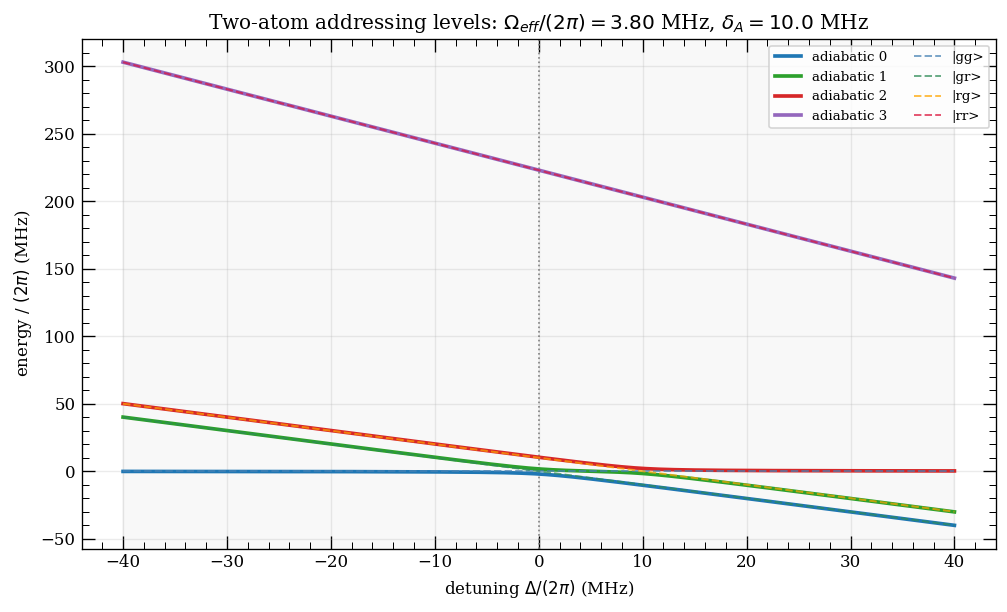

In [3]:
O420 = 135.0      # MHz
O1013 = 135.0     # MHz
Dint = 2.4        # GHz
dA = 10.0         # MHz, local pinning detuning
d420 = 0.0        # MHz
Vr = 213.0        # MHz
sweep_half = 40.0 # MHz
current_delta = 0.0

Oeff = O420 * O1013 / (2 * Dint * 1e3)
dtot = dA + d420
Delta2 = np.linspace(-sweep_half, sweep_half, 500)

# 直接按脚本写 Hamiltonian batch，不额外封装函数。
H = np.zeros((len(Delta2), 4, 4))
h = Oeff / 2
H[:, 0, 1] = H[:, 1, 0] = h
H[:, 0, 2] = H[:, 2, 0] = h
H[:, 1, 3] = H[:, 3, 1] = h
H[:, 2, 3] = H[:, 3, 2] = h
H[:, 1, 1] = -Delta2
H[:, 2, 2] = -Delta2 + dtot
H[:, 3, 3] = -2 * Delta2 + dtot + Vr
adiab = np.linalg.eigvalsh(H)

E_gg = np.zeros_like(Delta2)
E_gr = -Delta2
E_rg = -Delta2 + dtot
E_rr = -2 * Delta2 + dtot + Vr

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.axvspan(-sweep_half, sweep_half, color="lightgray", alpha=0.15)
ax.axvline(current_delta, color="gray", ls=":", lw=1)
for j, color in enumerate(["#1f77b4", "#2ca02c", "#d62728", "#9467bd"]):
    ax.plot(Delta2, adiab[:, j], lw=2.2, color=color, label=f"adiabatic {j}")
for y, label, color in [(E_gg, "|gg>", "steelblue"), (E_gr, "|gr>", "seagreen"), (E_rg, "|rg>", "orange"), (E_rr, "|rr>", "crimson")]:
    ax.plot(Delta2, y, "--", lw=1.2, color=color, alpha=0.7, label=label)
ax.set_xlabel(r"detuning $\Delta/(2\pi)$ (MHz)")
ax.set_ylabel(r"energy / $(2\pi)$ (MHz)")
ax.set_title(rf"Two-atom addressing levels: $\Omega_{{eff}}/(2\pi)={Oeff:.2f}$ MHz, $\delta_A={dtot:.1f}$ MHz")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()


## 2. AC Stark wavelength-power landscape

这个 block 对应 `plot_ac_stark_landscape.py` 的 landscape 部分。我们利用 `compute_shift_scatter` 得到参考功率下的 light shift 和 scattering，再按功率线性缩放成二维图。预期结果：shift 在 D lines 之间变号，scattering 在接近 resonance 时急剧上升。物理意义是寻找“足够大 Stark shift 但 scattering 可接受”的 addressing wavelength/power 区域。


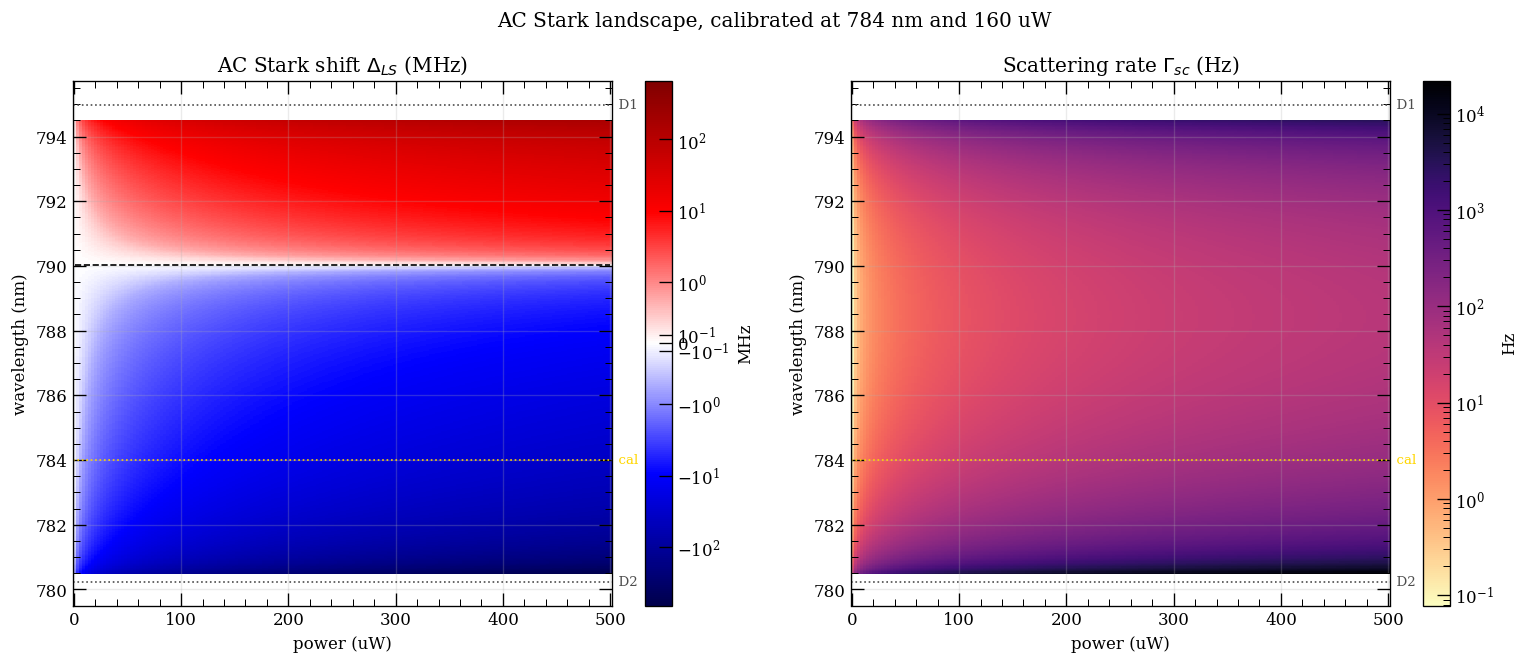

In [4]:
wl_nm = np.linspace(780.5, 794.5, 360)
power_uw = np.linspace(1.0, 500.0, 180)

shift_ref_hz, scatter_ref_hz = compute_shift_scatter(wl_nm)
scale = power_uw / POWER_REF_UW
shift_mhz = shift_ref_hz[:, None] * scale[None, :] / 1e6
scatter_hz = scatter_ref_hz[:, None] * scale[None, :]

fig, (ax_s, ax_sc) = plt.subplots(1, 2, figsize=(13, 5.6))
lin_thr = 0.5
vmax = float(np.nanmax(np.abs(shift_mhz)))
im_s = ax_s.pcolormesh(
    power_uw, wl_nm, shift_mhz, cmap="seismic",
    norm=SymLogNorm(linthresh=lin_thr, linscale=0.5, vmin=-vmax, vmax=vmax, base=10),
    shading="auto",
)
try:
    ax_s.contour(power_uw, wl_nm, shift_mhz, levels=[0.0], colors="k", linewidths=1.0, linestyles="--")
except ValueError:
    pass
for wl, label, color in [(LAMBDA_D1, "D1", "0.3"), (LAMBDA_D2, "D2", "0.3"), (LAMBDA_PAPER, "cal", "gold")]:
    ax_s.axhline(wl, color=color, lw=1, ls=":")
    ax_sc.axhline(wl, color=color, lw=1, ls=":")
    ax_s.text(power_uw[-1], wl, "  " + label, va="center", fontsize=8, color=color)
    ax_sc.text(power_uw[-1], wl, "  " + label, va="center", fontsize=8, color=color)
ax_s.set_title(r"AC Stark shift $\Delta_{LS}$ (MHz)")
ax_s.set_xlabel("power (uW)")
ax_s.set_ylabel("wavelength (nm)")
fig.colorbar(im_s, ax=ax_s, label="MHz")

sc_floor = max(1e-3, float(np.nanmin(scatter_hz[scatter_hz > 0])))
im_sc = ax_sc.pcolormesh(
    power_uw, wl_nm, np.clip(scatter_hz, sc_floor, None), cmap="magma_r",
    norm=LogNorm(vmin=sc_floor, vmax=float(np.nanmax(scatter_hz))), shading="auto",
)
ax_sc.set_title(r"Scattering rate $\Gamma_{sc}$ (Hz)")
ax_sc.set_xlabel("power (uW)")
ax_sc.set_ylabel("wavelength (nm)")
fig.colorbar(im_sc, ax=ax_sc, label="Hz")
fig.suptitle(rf"AC Stark landscape, calibrated at {LAMBDA_PAPER:.0f} nm and {POWER_REF_UW:.0f} uW")
fig.tight_layout()
plt.show()


## 3. AC Stark one-dimensional figures of merit

这个 block 对应 `plot_ac_stark_landscape.py` 的 profile、scatter-per-shift 和 required-shift plots。预期结果：不同 power 的 shift/scatter profile 形状相同、只按 power 线性缩放；`Γ_sc/|Δ_LS|` 是 power-independent 的 wavelength FOM。物理意义是把“要多少光强”与“这个 wavelength 本身是否干净”分离。


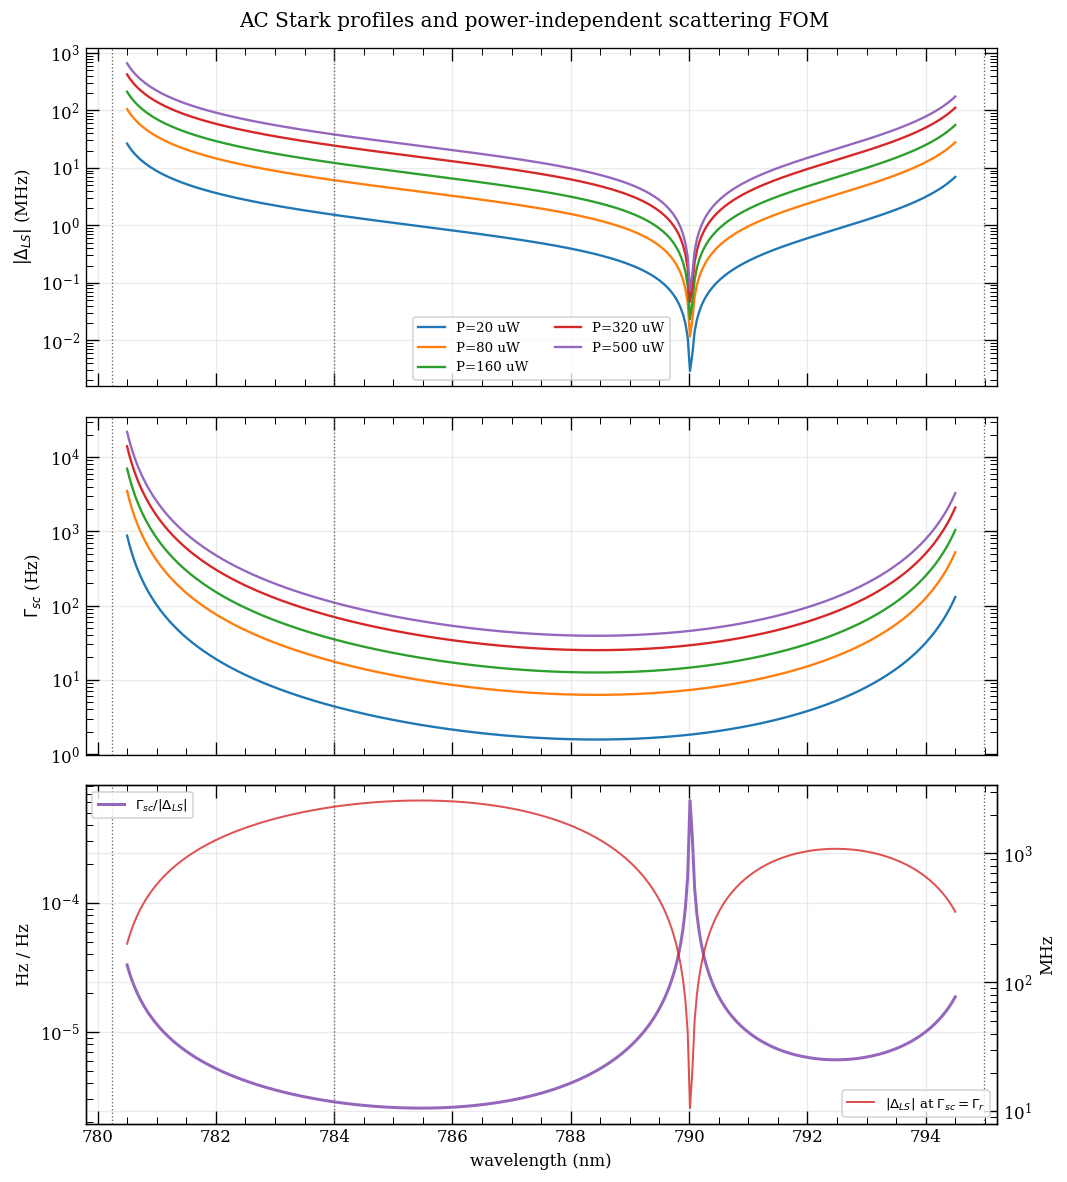

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
profile_powers = [20, 80, 160, 320, 500]
for P in profile_powers:
    shift_hz, scatter_hz_1d = compute_shift_scatter(wl_nm)
    s_mhz = shift_hz * (P / POWER_REF_UW) / 1e6
    sc_hz = scatter_hz_1d * (P / POWER_REF_UW)
    axes[0].plot(wl_nm, np.abs(s_mhz), lw=1.4, label=f"P={P} uW")
    axes[1].plot(wl_nm, sc_hz, lw=1.4, label=f"P={P} uW")

ratio = scatter_ref_hz / np.maximum(np.abs(shift_ref_hz), 1e-300)
gamma_ryd_hz = 1.0 / 151.55e-6
shift_match_mhz = gamma_ryd_hz / ratio / 1e6
axes[2].plot(wl_nm, ratio, lw=1.8, color="tab:purple", label=r"$\Gamma_{sc}/|\Delta_{LS}|$")
ax2 = axes[2].twinx()
ax2.plot(wl_nm, shift_match_mhz, lw=1.2, color="tab:red", alpha=0.8, label=r"$|\Delta_{LS}|$ at $\Gamma_{sc}=\Gamma_r$")

for ax in axes:
    ax.set_yscale("log")
    for line in (LAMBDA_D1, LAMBDA_D2, LAMBDA_PAPER):
        ax.axvline(line, color="0.4", lw=0.8, ls=":")
axes[0].set_ylabel(r"$|\Delta_{LS}|$ (MHz)")
axes[1].set_ylabel(r"$\Gamma_{sc}$ (Hz)")
axes[2].set_ylabel(r"Hz / Hz")
axes[2].set_xlabel("wavelength (nm)")
ax2.set_yscale("log")
ax2.set_ylabel("MHz")
axes[0].legend(ncol=2, fontsize=8)
axes[2].legend(loc="upper left", fontsize=8)
ax2.legend(loc="lower right", fontsize=8)
fig.suptitle("AC Stark profiles and power-independent scattering FOM")
fig.tight_layout()
plt.show()


## 4. Polarization and vector-Stark sensitivity

这个 block 对应 `plot_ac_stark_landscape.py` 的 polarization sensitivity 和 vector optimization。预期结果：少量 circular contamination 会移动 tune-out 并改变 vector sensitivity；在给定 784-786 nm window 内，可以选择一个 `|∂Δ/∂pol|/|Δ|` 较小的 wavelength。物理意义是 local addressing 不只要低 scattering，还要对 polarization impurity 不敏感。


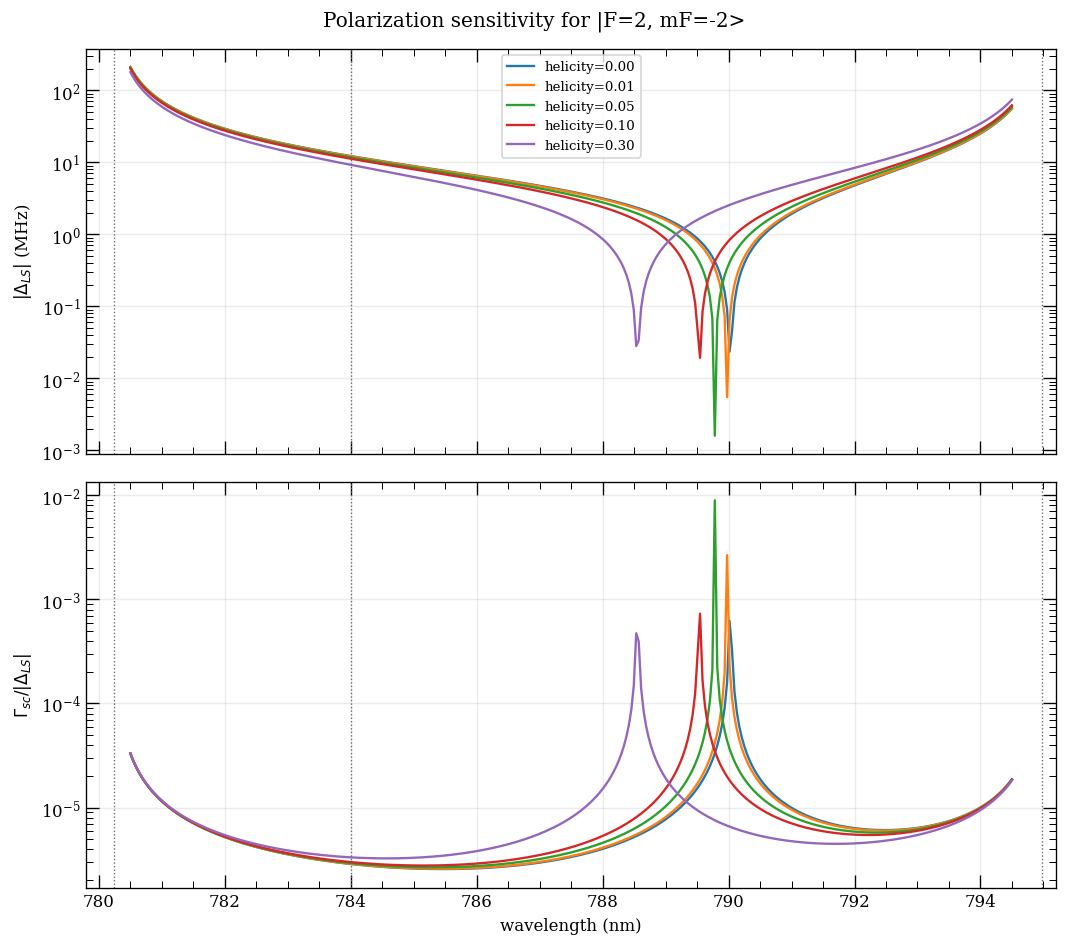

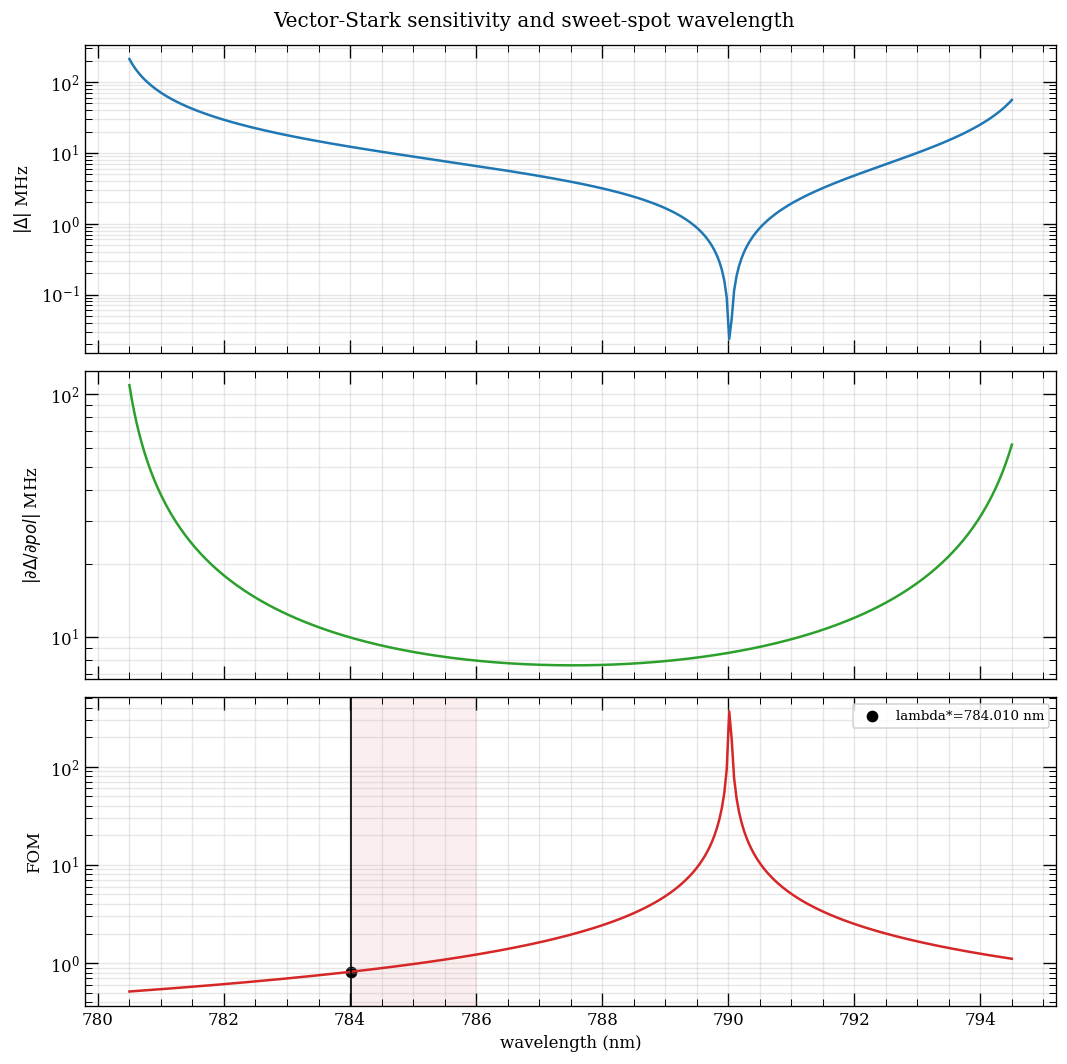

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
helicities = [0.0, 0.01, 0.05, 0.10, 0.30]
m_F = -2
for P_hel in helicities:
    pol = P_hel * G_F_5S12_F2 * m_F
    s_hz, sc_hz = compute_shift_scatter(wl_nm, pol=pol)
    axes[0].plot(wl_nm, np.abs(s_hz) / 1e6, lw=1.4, label=f"helicity={P_hel:.2f}")
    axes[1].plot(wl_nm, sc_hz / np.maximum(np.abs(s_hz), 1e-300), lw=1.4, label=f"helicity={P_hel:.2f}")
for ax in axes:
    ax.set_yscale("log")
    for line in (LAMBDA_D1, LAMBDA_D2, LAMBDA_PAPER):
        ax.axvline(line, color="0.4", lw=0.8, ls=":")
axes[0].set_ylabel(r"$|\Delta_{LS}|$ (MHz)")
axes[1].set_ylabel(r"$\Gamma_{sc}/|\Delta_{LS}|$")
axes[1].set_xlabel("wavelength (nm)")
axes[0].legend(fontsize=8)
fig.suptitle("Polarization sensitivity for |F=2, mF=-2>")
fig.tight_layout()
plt.show()

shift0_hz, _ = compute_shift_scatter(wl_nm, pol=0.0)
eps = 1e-3
shift_p, _ = compute_shift_scatter(wl_nm, pol=+eps)
shift_m, _ = compute_shift_scatter(wl_nm, pol=-eps)
dshift_dpol_mhz = (shift_p - shift_m) / (2 * eps) / 1e6
abs_scalar_mhz = np.abs(shift0_hz) / 1e6
fom = np.abs(dshift_dpol_mhz) / np.maximum(abs_scalar_mhz, 1e-300)
window = (wl_nm >= 784.0) & (wl_nm <= 786.0)
i_opt = int(np.argmin(np.where(window, fom, np.inf)))

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
axes[0].plot(wl_nm, abs_scalar_mhz, lw=1.5)
axes[1].plot(wl_nm, np.abs(dshift_dpol_mhz), lw=1.5, color="tab:green")
axes[2].plot(wl_nm, fom, lw=1.5, color="tab:red")
axes[2].axvspan(784, 786, color="tab:red", alpha=0.08)
axes[2].axvline(wl_nm[i_opt], color="k", lw=1.0)
axes[2].scatter([wl_nm[i_opt]], [fom[i_opt]], color="k", label=f"lambda*={wl_nm[i_opt]:.3f} nm")
for ax in axes:
    ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")
axes[0].set_ylabel(r"$|\Delta|$ MHz")
axes[1].set_ylabel(r"$|\partial\Delta/\partial pol|$ MHz")
axes[2].set_ylabel("FOM")
axes[2].set_xlabel("wavelength (nm)")
axes[2].legend(fontsize=8)
fig.suptitle("Vector-Stark sensitivity and sweet-spot wavelength")
fig.tight_layout()
plt.show()


## 5. Rabi dynamics: blockade versus addressed atom

这个 block 对应 `run_local_sweep.py` 的 Figure 1。我们比较 global resonant drive 和 atom A 被 local detuning pin 住时的 Rabi dynamics。预期结果：global drive 下 blockade 使两个原子只能集体振荡；addressed case 下 atom A 基本不进 Rydberg，atom B 可以自由振荡。物理意义是 local addressing 如何绕开/破坏两原子 blockade dynamics。


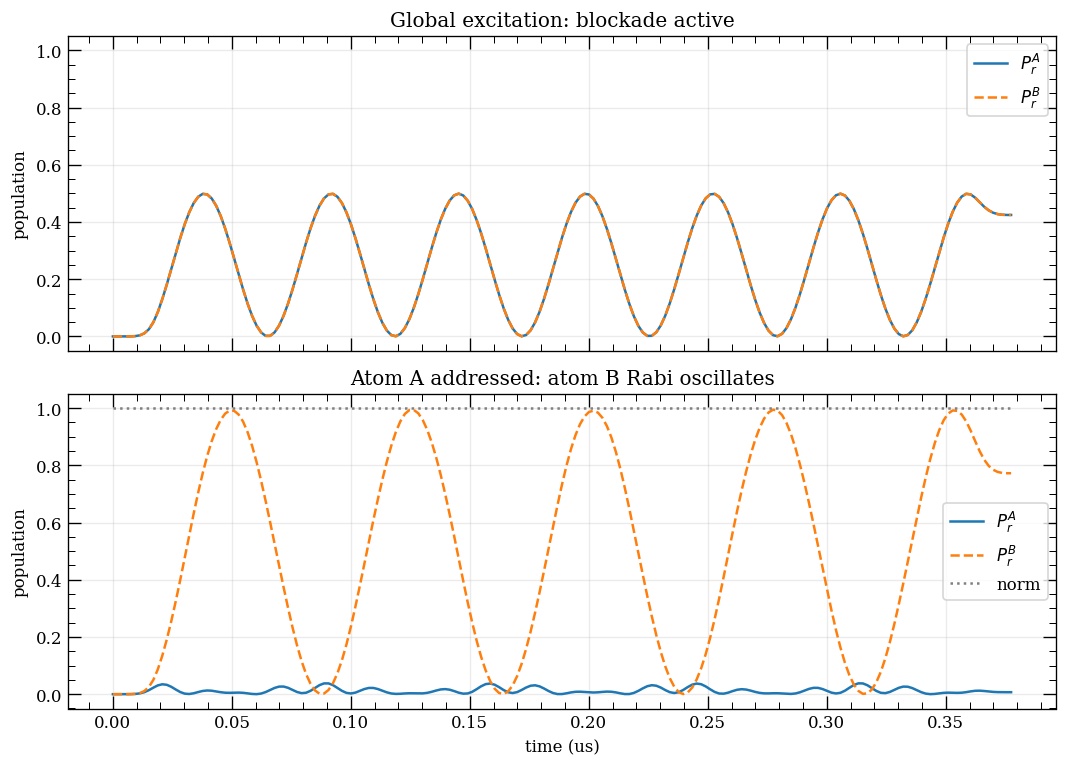

In [7]:
N_LEVELS = 3
LOCAL_DETUNING = -2 * pi * 50e6
LOCAL_SCATTER = 150.0
DELTA_START = -2 * pi * 40e6
DELTA_END = 2 * pi * 40e6
T_GATE = 4.5e-6
PRODUCT_STATES = build_product_state_map(n_levels=N_LEVELS)
psi_gg = PRODUCT_STATES["gg"]

model = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "analog_3", detuning_sign=1)
time_scale = model.meta("time_scale")
t_rabi = 5 * time_scale
x_rabi = [0.0, 0.0, t_rabi / time_scale]
t_eval = np.linspace(0, t_rabi, 500)

proto_free = AnalogSweepProtocol()
proto_addr = AnalogSweepProtocol(addressing={0: LOCAL_DETUNING}, scatter_rate=LOCAL_SCATTER)
res_free = simulate(model.with_protocol(proto_free), x_rabi, psi_gg, t_eval=t_eval)
res_addr = simulate(model.with_protocol(proto_addr), x_rabi, psi_gg, t_eval=t_eval)
obs_free = measure_trajectory(model, res_free.states, ["n_r_0", "n_r_1"])
obs_addr = measure_trajectory(model, res_addr.states, ["n_r_0", "n_r_1"])
norm_addr = np.array([norm_squared(res_addr.states[k]) for k in range(res_addr.states.shape[0])])

fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)
axes[0].plot(res_free.times * 1e6, obs_free["n_r_0"], label=r"$P_r^A$")
axes[0].plot(res_free.times * 1e6, obs_free["n_r_1"], "--", label=r"$P_r^B$")
axes[0].set_title("Global excitation: blockade active")
axes[1].plot(res_addr.times * 1e6, obs_addr["n_r_0"], label=r"$P_r^A$")
axes[1].plot(res_addr.times * 1e6, obs_addr["n_r_1"], "--", label=r"$P_r^B$")
axes[1].plot(res_addr.times * 1e6, norm_addr, ":", color="gray", label="norm")
axes[1].set_title("Atom A addressed: atom B Rabi oscillates")
for ax in axes:
    ax.set_ylabel("population")
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
axes[1].set_xlabel("time (us)")
fig.tight_layout()
plt.show()


## 6. Adiabatic sweep and AC-Stark feed-forward

这个 block 对应 `run_local_sweep.py` 的 final population 与 Stark compensation 部分。预期结果：没有 feed-forward 时，Blackman envelope 带来的 ground-state AC Stark shift 会扭曲 sweep；加入 `ac_stark_shift` 后，目标 final population 更接近预期。物理意义是 local addressing 的 sweep fidelity 依赖相位/频率补偿，而不只是静态 detuning 大小。


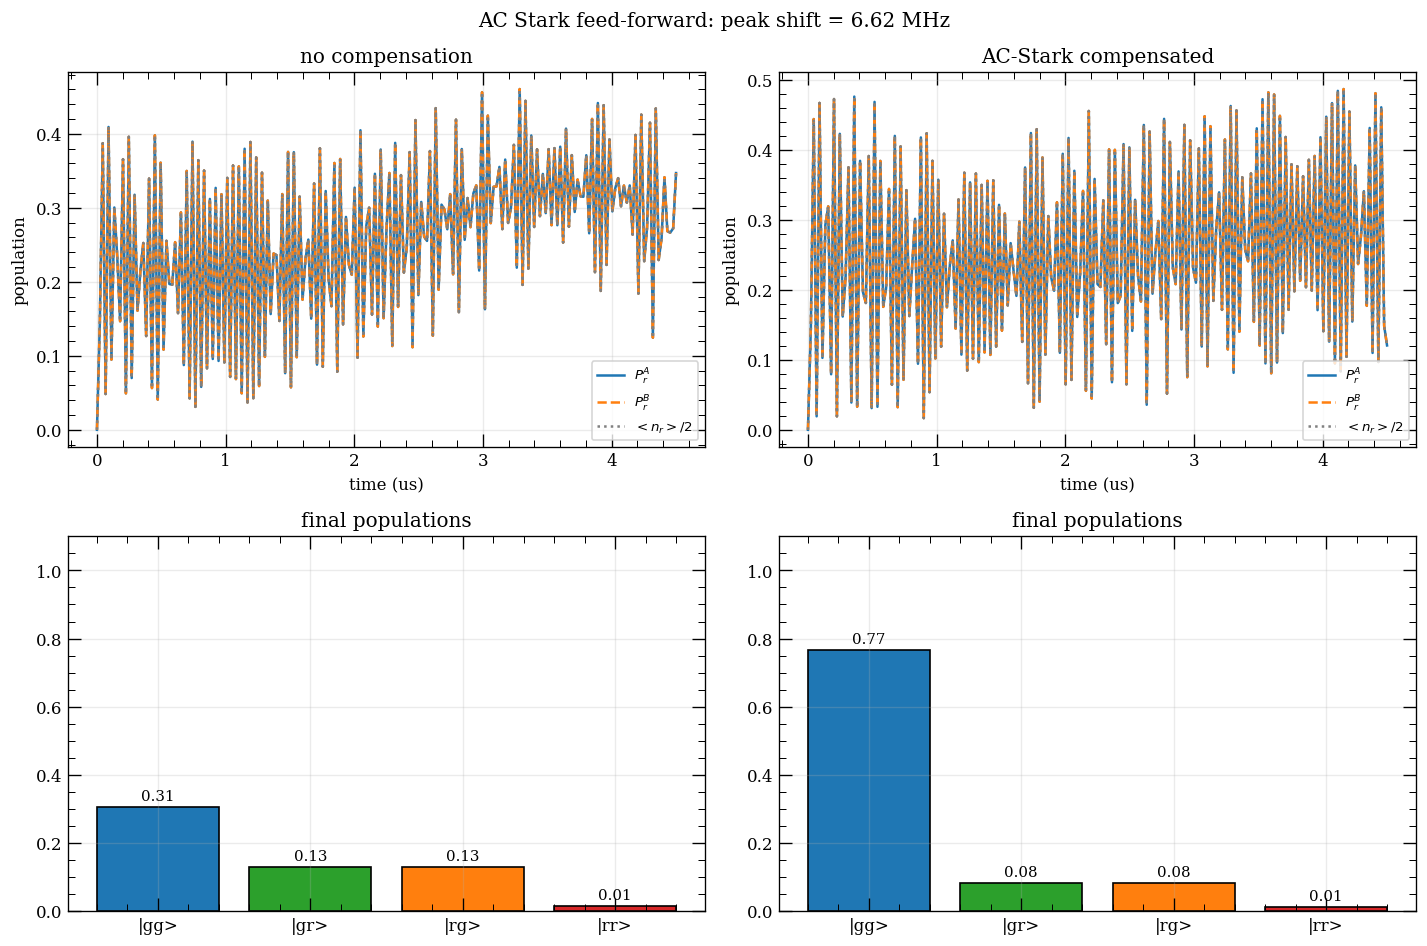

In [8]:
rabi_eff = model.meta("rabi_eff")
time_scale = model.meta("time_scale")
rabi_420 = model.meta("rabi_420")
Delta = model.meta("Delta")
ac_stark_peak = rabi_420**2 / (4 * abs(Delta))
x_sweep = [DELTA_START / rabi_eff, DELTA_END / rabi_eff, T_GATE / time_scale]

proto_raw = AnalogSweepProtocol(ac_stark_shift=0.0)
proto_comp = AnalogSweepProtocol(ac_stark_shift=ac_stark_peak)
res_raw = simulate(model.with_protocol(proto_raw), x_sweep, psi_gg, t_eval=np.linspace(0, T_GATE, 500))
res_comp = simulate(model.with_protocol(proto_comp), x_sweep, psi_gg, t_eval=np.linspace(0, T_GATE, 500))
obs_raw = measure_trajectory(model, res_raw.states, ["n_r_0", "n_r_1", "sum_n_r"])
obs_comp = measure_trajectory(model, res_comp.states, ["n_r_0", "n_r_1", "sum_n_r"])

keys = ["gg", "gr", "rg", "rr"]
pops_raw = {k: basis_pop(model, res_raw.psi_final, k) for k in keys}
pops_comp = {k: basis_pop(model, res_comp.psi_final, k) for k in keys}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, (obs, pops_final, title) in enumerate([(obs_raw, pops_raw, "no compensation"), (obs_comp, pops_comp, "AC-Stark compensated")]):
    ax = axes[0, col]
    ax.plot(res_raw.times * 1e6, obs["n_r_0"], label=r"$P_r^A$")
    ax.plot(res_raw.times * 1e6, obs["n_r_1"], "--", label=r"$P_r^B$")
    ax.plot(res_raw.times * 1e6, obs["sum_n_r"] / 2, ":", color="gray", label=r"$<n_r>/2$")
    ax.set_title(title)
    ax.set_xlabel("time (us)")
    ax.set_ylabel("population")
    ax.legend(fontsize=8)

    ax = axes[1, col]
    vals = [pops_final[k] for k in keys]
    ax.bar(range(len(keys)), vals, color=["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"], edgecolor="black")
    ax.set_xticks(range(len(keys)), [f"|{k}>" for k in keys])
    ax.set_ylim(0, 1.1)
    ax.set_title("final populations")
    for j, v in enumerate(vals):
        ax.text(j, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
fig.suptitle(rf"AC Stark feed-forward: peak shift = {ac_stark_peak/(2*pi)/1e6:.2f} MHz")
fig.tight_layout()
plt.show()


## 7. Landau-Zener diagnostic for the sweep

这个 block 对应 `run_local_sweep.py` 的 Landau-Zener figure。我们扫描 sweep time，拟合 `P_defect = exp(-C Ω_eff²/v)`。预期结果：在足够宽的 sweep window 下，拟合常数 `C` 接近理论量级。物理意义是判断 sweep error 是否来自 diabatic LZ transition，还是来自有限边界/错误 crossing 等别的机制。


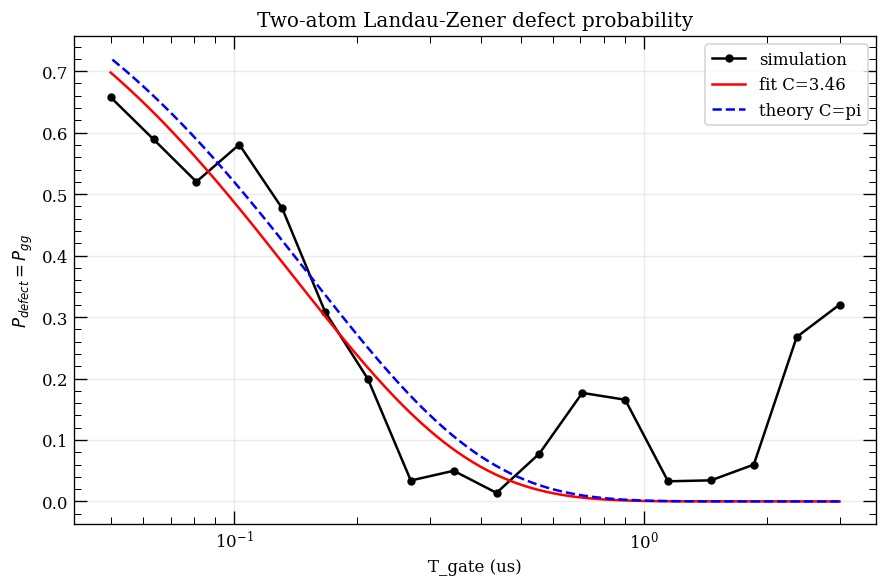

In [9]:
from scipy.optimize import curve_fit

model_sq = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "analog_3", detuning_sign=1, blackmanflag=False)
Omega_eff = model_sq.meta("rabi_eff")
time_scale = model_sq.meta("time_scale")
ds = -20 * Omega_eff
de = 20 * Omega_eff
delta_range = de - ds
t_gates = np.logspace(np.log10(0.05e-6), np.log10(3e-6), 18)
sweep_rates = delta_range / t_gates
p_defect = np.empty(len(t_gates))
p_af = np.empty(len(t_gates))
sweep_system = model_sq.with_protocol(AnalogSweepProtocol())

for i, t_g in enumerate(t_gates):
    x = [ds / Omega_eff, de / Omega_eff, t_g / time_scale]
    result = simulate(sweep_system, x, psi_gg)
    p_defect[i] = basis_pop(model_sq, result.psi_final, "gg")
    p_af[i] = basis_pop(model_sq, result.psi_final, "gr") + basis_pop(model_sq, result.psi_final, "rg")

mask = (p_defect > 0.005) & (p_defect < 0.95)
if mask.sum() >= 3:
    popt, pcov = curve_fit(lambda v, C: np.exp(np.clip(-C * Omega_eff**2 / v, -500, 0)), sweep_rates[mask], p_defect[mask], p0=[np.pi])
    C_fit = float(popt[0])
else:
    C_fit = np.pi

v_fine = np.logspace(np.log10(sweep_rates.min()), np.log10(sweep_rates.max()), 200)
t_fine_us = delta_range / v_fine * 1e6
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(t_gates * 1e6, p_defect, "ko-", ms=4, label="simulation")
ax.plot(t_fine_us, np.exp(np.clip(-C_fit * Omega_eff**2 / v_fine, -500, 0)), "r-", label=f"fit C={C_fit:.2f}")
ax.plot(t_fine_us, np.exp(np.clip(-np.pi * Omega_eff**2 / v_fine, -500, 0)), "b--", label="theory C=pi")
ax.set_xscale("log")
ax.set_xlabel("T_gate (us)")
ax.set_ylabel(r"$P_{defect}=P_{gg}$")
ax.set_title("Two-atom Landau-Zener defect probability")
ax.legend()
fig.tight_layout()
plt.show()


## 8. Single-qubit wavelength-power scan

这个 block 对应 `scan_local_addressing_singlequbit.py`。单原子模型把两件事拆开：atom A 被强 detuning pin 住，virtual atom B 只感受到 Gaussian tail `η δ_A` 并应完成 adiabatic passage。预期结果是 total cost heatmap，其中最佳点折中 not-pinned、crosstalk 和 scattering。物理意义是先在没有 Rydberg interaction 的模型里理解参数趋势。

默认不重算。如果已有 `results/addressing_1q_grid.csv`，会直接画图；否则把 `RUN_SINGLE_QUBIT_SCAN=True` 会跑一个较小 quick scan。


In [10]:
RUN_SINGLE_QUBIT_SCAN = False
single_csv = REPO_ROOT / "results" / "addressing_1q_grid.csv"
GRID_1Q_DTYPE = [
    ("wl", float), ("power_uw", float), ("delta_A_mhz", float), ("delta_B_mhz", float), ("scatter_A_hz", float),
    ("P_g_A", float), ("P_e_A", float), ("P_r_A", float), ("P_g_B", float), ("P_e_B", float), ("P_r_B", float),
    ("not_pinned", float), ("leakage", float), ("crosstalk", float), ("scatter_penalty", float), ("total_cost", float),
    ("delta_A_over_Omega", float),
]

grid_1q = None
if single_csv.exists():
    raw = np.loadtxt(single_csv, delimiter=",", dtype=float)
    if raw.ndim == 1:
        raw = raw.reshape(1, -1)
    grid_1q = np.empty(raw.shape[0], dtype=GRID_1Q_DTYPE)
    for i, name in enumerate(grid_1q.dtype.names):
        grid_1q[name] = raw[:, i]
    print(f"Loaded {single_csv}")
elif RUN_SINGLE_QUBIT_SCAN:
    rabi_420_hz = 135e6
    system_1q = RydbergSystem.from_lattice(Register.chain(1, spacing_um=3.0), "analog_3", detuning_sign=1, blackmanflag=True, Delta_Hz=2.4e9, rabi_420_Hz=rabi_420_hz, rabi_1013_Hz=135e6)
    rabi_eff_1q = system_1q.meta("rabi_eff")
    time_scale_1q = system_1q.meta("time_scale")
    Delta_1q = system_1q.meta("Delta")
    psi0_1q = np.array([1.0, 0.0, 0.0], dtype=complex)
    ac_peak_1q = (2 * pi * rabi_420_hz) ** 2 / (4 * abs(Delta_1q))
    distance_um, waist_um = 4.0, 1.0
    eta = np.exp(-2 * (distance_um / waist_um) ** 2)
    t_gate_us = 4.5
    x_1q = [2 * pi * -40e6 / rabi_eff_1q, 2 * pi * 40e6 / rabi_eff_1q, t_gate_us * 1e-6 / time_scale_1q]
    wls = np.linspace(781.0, 786.0, 10)
    powers = np.linspace(160.0, 500.0, 10)
    grid_1q = np.empty(len(wls) * len(powers), dtype=GRID_1Q_DTYPE)
    idx = 0
    for wl in wls:
        s_ref, sc_ref = compute_shift_scatter(wl)
        for power in powers:
            scale = power / POWER_REF_UW
            delta_A = 2 * pi * float(s_ref) * scale
            delta_B = eta * delta_A
            scatter_A = float(sc_ref) * scale
            psi_A = simulate(system_1q.with_protocol(AnalogSweepProtocol(addressing={0: delta_A}, ac_stark_shift=ac_peak_1q)), x_1q, psi0_1q).psi_final
            psi_B = simulate(system_1q.with_protocol(AnalogSweepProtocol(addressing={0: delta_B}, ac_stark_shift=ac_peak_1q)), x_1q, psi0_1q).psi_final
            P_g_A, P_e_A, P_r_A = np.abs(psi_A) ** 2
            P_g_B, P_e_B, P_r_B = np.abs(psi_B) ** 2
            not_pinned = 1.0 - P_g_A
            crosstalk = 1.0 - P_r_B
            scatter_pen = 1.0 - np.exp(-scatter_A * t_gate_us * 1e-6)
            grid_1q[idx] = (wl, power, delta_A/(2*pi*1e6), delta_B/(2*pi*1e6), scatter_A, P_g_A, P_e_A, P_r_A, P_g_B, P_e_B, P_r_B, not_pinned, P_e_A, crosstalk, scatter_pen, not_pinned + crosstalk + scatter_pen, abs(delta_A)/rabi_eff_1q)
            idx += 1
else:
    print("No single-qubit CSV found. Set RUN_SINGLE_QUBIT_SCAN=True for a quick scan.")

if grid_1q is not None:
    wls = np.unique(grid_1q["wl"])
    powers = np.unique(grid_1q["power_uw"])
    best = grid_1q[np.argmin(grid_1q["total_cost"])]
    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    for ax, field, title, cmap in zip(
        axes.flat,
        ["not_pinned", "crosstalk", "scatter_penalty", "total_cost"],
        ["not pinned", "crosstalk", "scatter", "total cost"],
        ["Reds", "Blues", "Oranges", "viridis_r"],
    ):
        data = grid_1q[field].reshape(len(wls), len(powers))
        im = ax.pcolormesh(powers, wls, data, cmap=cmap, shading="auto")
        ax.plot(best["power_uw"], best["wl"], "k*", ms=12)
        ax.set_xlabel("power (uW)")
        ax.set_ylabel("wavelength (nm)")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
    fig.suptitle(f"Single-qubit scan best: lambda={best['wl']:.2f} nm, P={best['power_uw']:.1f} uW")
    fig.tight_layout()
    plt.show()


No single-qubit CSV found. Set RUN_SINGLE_QUBIT_SCAN=True for a quick scan.


## 9. Two-atom optimization scan from saved CSV

这个 block 对应 `scan_local_addressing.py optimize-plot`。默认从 `results/exp5_addressing_opt_grid.csv`、`exp4`、`exp3`、`exp2`、`exp1` 中找已有结果，不重跑 simulation。预期结果是 cost components heatmap 或 sweep-axis heatmap。物理意义是把 pinning leak、crosstalk、scattering 三个 competing constraints 放在同一参数平面里看。


Loaded /home/chance/Ryd-gate-modeling/results/exp5_addressing_opt_grid.csv with 2400 points


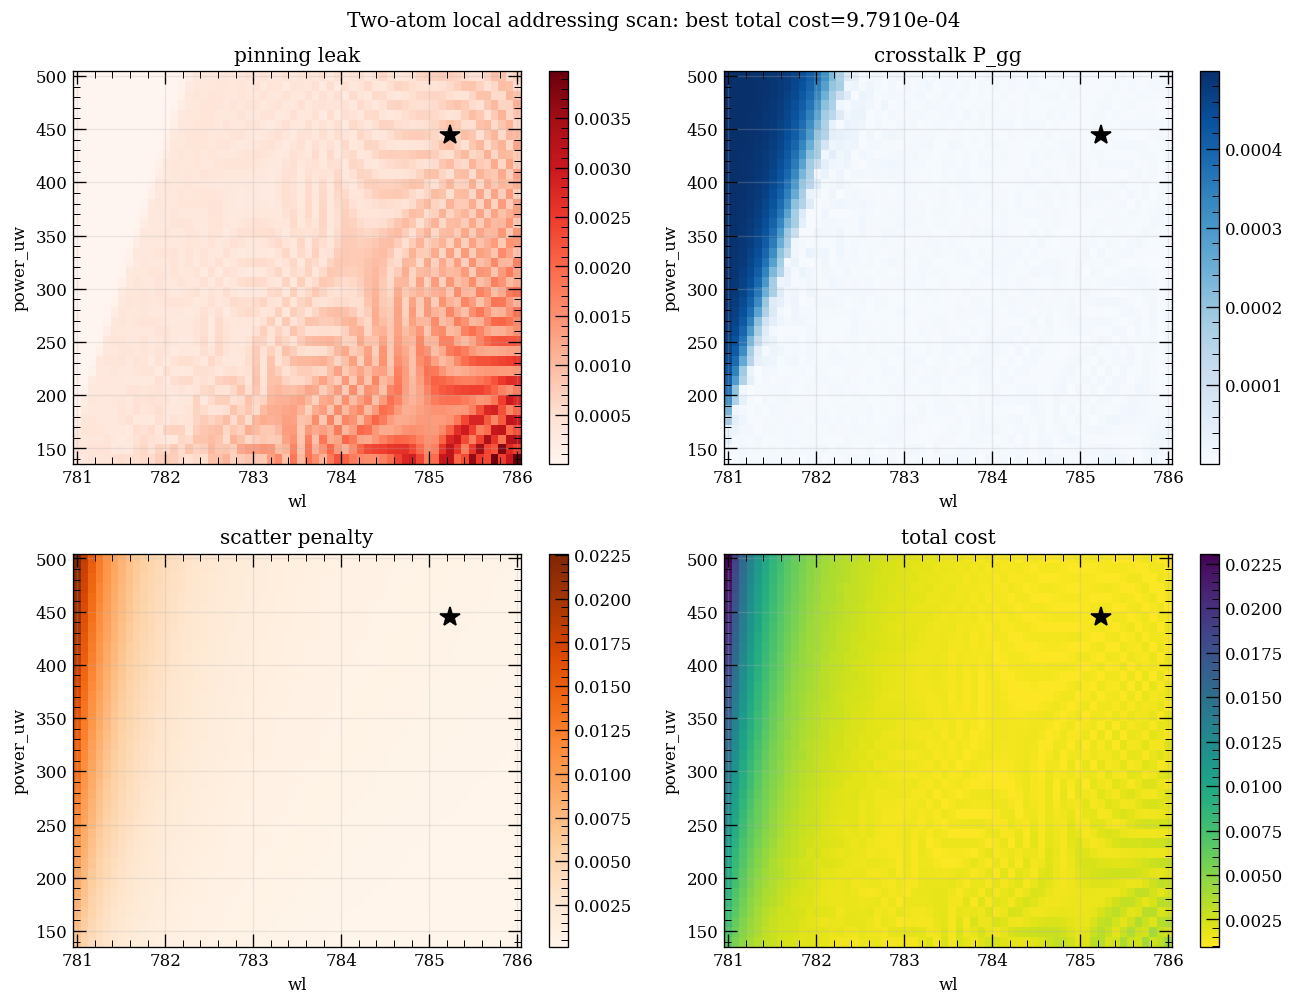

Best point: lambda `785.237` nm, power `444.6` uW, delta_A `-22.900` MHz, P_gr `0.99876`, total cost `9.79103e-04`.

In [11]:
candidates = [REPO_ROOT / "results" / f"exp{i}_addressing_opt_grid.csv" for i in (5, 4, 3, 2, 1)]
scan_csv = next((p for p in candidates if p.exists()), None)

if scan_csv is None:
    print("No two-atom scan CSV found. Use the scan logic in this notebook or restore cached results before plotting.")
else:
    raw = np.loadtxt(scan_csv, delimiter=",", dtype=float)
    if raw.ndim == 1:
        raw = raw.reshape(1, -1)
    dtype_legacy = [
        ("wl", float), ("power_uw", float), ("delta_A_mhz", float), ("delta_B_mhz", float), ("scatter_A_hz", float),
        ("P_gg", float), ("P_gr", float), ("P_rg", float), ("P_rr", float), ("pinning_leak", float),
        ("crosstalk", float), ("scatter_penalty", float), ("total_cost", float), ("P_target", float), ("other_residual", float),
        ("delta_A_over_Omega", float), ("delta_A_over_V", float),
    ]
    dtype_new = dtype_legacy + [("delta_half_mhz", float), ("t_gate_us", float)]
    dtype = dtype_new if raw.shape[1] == 19 else dtype_legacy
    grid = np.empty(raw.shape[0], dtype=dtype)
    for i, name in enumerate(grid.dtype.names):
        grid[name] = raw[:, i]
    if raw.shape[1] == 17:
        new_grid = np.empty(len(grid), dtype=dtype_new)
        for name in grid.dtype.names:
            new_grid[name] = grid[name]
        new_grid["delta_half_mhz"] = 40.0
        new_grid["t_gate_us"] = 4.5
        grid = new_grid

    print(f"Loaded {scan_csv} with {len(grid)} points")
    best = grid[np.argmin(grid["total_cost"])]
    varying = [(name, np.unique(grid[name])) for name in ("wl", "power_uw", "delta_half_mhz", "t_gate_us") if len(np.unique(grid[name])) > 1]
    if len(varying) >= 2:
        x_name, x_vals = varying[0]
        y_name, y_vals = varying[1]
        fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
        for ax, field, title, cmap in zip(
            axes.flat,
            ["pinning_leak", "crosstalk", "scatter_penalty", "total_cost"],
            ["pinning leak", "crosstalk P_gg", "scatter penalty", "total cost"],
            ["Reds", "Blues", "Oranges", "viridis_r"],
        ):
            Z = np.full((len(y_vals), len(x_vals)), np.nan)
            for row in grid:
                ix = int(np.argmin(np.abs(x_vals - row[x_name])))
                iy = int(np.argmin(np.abs(y_vals - row[y_name])))
                Z[iy, ix] = row[field]
            im = ax.pcolormesh(x_vals, y_vals, Z, cmap=cmap, shading="auto")
            ax.plot(best[x_name], best[y_name], "k*", ms=12)
            ax.set_xlabel(x_name)
            ax.set_ylabel(y_name)
            ax.set_title(title)
            fig.colorbar(im, ax=ax)
        fig.suptitle(f"Two-atom local addressing scan: best total cost={best['total_cost']:.4e}")
        fig.tight_layout()
        plt.show()
    display(Markdown(
        f"Best point: lambda `{best['wl']:.3f}` nm, power `{best['power_uw']:.1f}` uW, "
        f"delta_A `{best['delta_A_mhz']:.3f}` MHz, P_gr `{best['P_gr']:.5f}`, total cost `{best['total_cost']:.5e}`."
    ))


## 10. Optional noise scan and adiabaticity diagnosis

这个 block 对应 `scan_local_addressing.py noise` 和 `diagnose_adiabaticity.py`。两者都可能比较耗时，因此默认不跑；如果已有诊断图，会直接 display。预期结果：noise scan 给出 pinning/crosstalk/leakage 对 detuning/RIN/amplitude noise 的敏感性；adiabaticity diagnosis 区分真实 diabatic dropout 和 `eigh` near-degeneracy 造成的 top-1 overlap artifact。物理意义是避免把 finite-boundary 或 basis-rotation artifact 错判成“扫得不够慢”。


In [12]:
RUN_NOISE_SCAN = False
RUN_ADIABATIC_DIAGNOSIS = False

if RUN_NOISE_SCAN:
    from ryd_gate.analysis.local_addressing import (
        BASELINE_AMP,
        BASELINE_DETUNING_HZ,
        BASELINE_RIN,
        COMBINED_SCALE_MAX,
        DEFAULT_LOCAL_DETUNING,
        DEFAULT_LOCAL_SCATTER,
        default_sweep_x,
        evaluate_addressing,
    )

    system_noise = RydbergSystem.from_lattice(Register.chain(2, spacing_um=3.0), "analog_3", detuning_sign=1)
    initial_state = build_product_state_map(n_levels=3)["gg"]
    protocol_noise = AnalogSweepProtocol(addressing={0: DEFAULT_LOCAL_DETUNING}, scatter_rate=DEFAULT_LOCAL_SCATTER)
    x_noise = default_sweep_x(system_noise)
    n_points = 8
    n_mc = 50
    scans = {
        "Global detuning": ("sigma_detuning", np.linspace(0, 500e3, n_points), 1e-3, "detuning noise (kHz)"),
        "Local RIN": ("sigma_local_rin", np.linspace(0, 0.05, n_points), 100, "RIN (%)"),
        "Amplitude noise": ("sigma_amplitude", np.linspace(0, 0.05, n_points), 100, "amplitude noise (%)"),
    }
    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    for ax, (title, (param, values, xscale, xlabel)) in zip(axes.flat, scans.items()):
        pin_errs, xtalk_errs, leak_errs = [], [], []
        for value in values:
            kwargs = {"sigma_detuning": 0.0, "sigma_local_rin": 0.0, "sigma_amplitude": 0.0}
            kwargs[param] = float(value)
            pin, xtalk, leak = evaluate_addressing(system_noise, initial_state, protocol_noise, x_noise, kwargs, n_mc)
            pin_errs.append(pin)
            xtalk_errs.append(xtalk)
            leak_errs.append(leak)
        ax.plot(values * xscale, pin_errs, "o-", label="pinning")
        ax.plot(values * xscale, xtalk_errs, "s-", label="crosstalk")
        ax.plot(values * xscale, leak_errs, "^-", label="leakage")
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("error")
        ax.legend(fontsize=8)

    ax = axes.flat[3]
    scale_factors = np.linspace(0, COMBINED_SCALE_MAX, n_points)
    pin_comb, xtalk_comb, leak_comb = [], [], []
    for scale in scale_factors:
        pin, xtalk, leak = evaluate_addressing(
            system_noise,
            initial_state,
            protocol_noise,
            x_noise,
            {
                "sigma_detuning": BASELINE_DETUNING_HZ * scale,
                "sigma_local_rin": BASELINE_RIN * scale,
                "sigma_amplitude": BASELINE_AMP * scale,
            },
            n_mc,
        )
        pin_comb.append(pin)
        xtalk_comb.append(xtalk)
        leak_comb.append(leak)
    ax.plot(scale_factors, pin_comb, "o-", label="pinning")
    ax.plot(scale_factors, xtalk_comb, "s-", label="crosstalk")
    ax.plot(scale_factors, leak_comb, "^-", label="leakage")
    ax.axvline(1.0, color="green", ls=":", label="baseline")
    ax.set_title("Combined noise")
    ax.set_xlabel("noise scale factor")
    ax.set_ylabel("error")
    ax.legend(fontsize=8)
    fig.suptitle("Addressing noise sensitivity")
    fig.tight_layout()
    plt.show()

if RUN_ADIABATIC_DIAGNOSIS:
    DISTANCE_UM = 4.0
    WAIST_UM = 1.0
    WL_REF_NM = 783.5
    P_REF_UW = 320.0
    DELTA_START_MHZ = -40.0
    DELTA_END_MHZ = 40.0
    model_diag = RydbergSystem.from_lattice(
        Register.chain(2, spacing_um=DISTANCE_UM),
        "analog_3",
        detuning_sign=1,
        blackmanflag=True,
        Delta_Hz=2.4e9,
        rabi_420_Hz=135e6,
        rabi_1013_Hz=135e6,
    )
    rabi_eff = model_diag.meta("rabi_eff")
    time_scale = model_diag.meta("time_scale")
    rabi_420 = model_diag.meta("rabi_420")
    Delta = model_diag.meta("Delta")
    eta = np.exp(-2 * (DISTANCE_UM / WAIST_UM) ** 2)
    shift_ref, _ = compute_shift_scatter(WL_REF_NM)
    delta_A = 2 * pi * float(shift_ref) * (P_REF_UW / POWER_REF_UW)
    delta_B = eta * delta_A
    ac_stark_peak = rabi_420**2 / (4 * abs(Delta))
    protocol_diag = AnalogSweepProtocol(addressing={0: delta_A, 1: delta_B}, ac_stark_shift=ac_stark_peak)
    psi0 = np.zeros(9, dtype=complex)
    psi0[0] = 1.0

    T_us = 4.5
    x_diag = [2 * pi * DELTA_START_MHZ * 1e6 / rabi_eff, 2 * pi * DELTA_END_MHZ * 1e6 / rabi_eff, T_us * 1e-6 / time_scale]
    system_diag = model_diag.with_protocol(protocol_diag)
    params_diag = system_diag.unpack_params(x_diag)
    t_eval = np.linspace(0.0, params_diag["t_gate"], 251)
    result_diag = simulate(system_diag, x_diag, psi0, t_eval=t_eval)
    ham = compile_hamiltonian_ir(system_diag, params_diag)
    ir = compile_expm_ir(ham)
    F1 = np.empty(len(result_diag.times))
    F2 = np.empty(len(result_diag.times))
    for i, (t, psi) in enumerate(zip(result_diag.times, result_diag.states)):
        H = np.zeros((ir.dim, ir.dim), dtype=complex)
        for term in ir.static_terms:
            coeff = term.coefficient(0) if callable(term.coefficient) else term.coefficient
            H += coeff * np.asarray(term.operator)
        for term in ir.drive_terms:
            coeff = term.coefficient(t) if callable(term.coefficient) else term.coefficient
            H += coeff * np.asarray(term.operator)
        H = 0.5 * (H + H.conj().T)
        _, evecs = np.linalg.eigh(H)
        overlaps = np.abs(evecs.conj().T @ psi) ** 2
        F1[i] = overlaps.max()
        F2[i] = np.partition(overlaps, -2)[-2:].sum()
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.semilogy(result_diag.times * 1e6, np.maximum(1 - F1, 1e-16), color="0.6", label="1 - top-1 overlap")
    ax.semilogy(result_diag.times * 1e6, np.maximum(1 - F2, 1e-16), color="k", label="1 - top-2 overlap")
    ax.set_xlabel("time (us)")
    ax.set_ylabel("dropout")
    ax.set_title("Adiabaticity diagnosis: top-1 artifact vs top-2 subspace")
    ax.legend()
    fig.tight_layout()
    plt.show()

    rows = []
    for T_us in np.array([1.0, 2.0, 4.5, 9.0, 20.0]):
        x = [2 * pi * DELTA_START_MHZ * 1e6 / rabi_eff, 2 * pi * DELTA_END_MHZ * 1e6 / rabi_eff, T_us * 1e-6 / time_scale]
        psi_f = simulate(model_diag.with_protocol(protocol_diag), x, psi0).psi_final
        rows.append([
            T_us,
            model_diag.observables.measure("pop_gg", psi_f),
            model_diag.observables.measure("pop_gr", psi_f),
            model_diag.observables.measure("pop_rg", psi_f),
            model_diag.observables.measure("pop_rr", psi_f),
        ])
    rows = np.asarray(rows)
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.loglog(rows[:, 0], np.maximum(rows[:, 1], 1e-16), "o-", label="P_gg")
    ax.loglog(rows[:, 0], np.maximum(rows[:, 3], 1e-16), "s-", label="P_rg")
    ax.loglog(rows[:, 0], np.maximum(1 - rows[:, 2], 1e-16), "x--", label="1 - P_gr")
    ax.set_xlabel("T_gate (us)")
    ax.set_ylabel("population")
    ax.set_title("Slow-sweep diagnosis at fixed sweep window")
    ax.legend()
    fig.tight_layout()
    plt.show()

    alpha_ref = (2 * abs(DELTA_START_MHZ)) / 4.5
    boundary_rows = []
    for dmax in np.array([20.0, 30.0, 40.0, 60.0, 80.0, 120.0, 160.0]):
        T_us = (2 * dmax) / alpha_ref
        x = [2 * pi * -dmax * 1e6 / rabi_eff, 2 * pi * dmax * 1e6 / rabi_eff, T_us * 1e-6 / time_scale]
        psi_f = simulate(model_diag.with_protocol(protocol_diag), x, psi0).psi_final
        boundary_rows.append([
            dmax,
            T_us,
            model_diag.observables.measure("pop_gg", psi_f),
            model_diag.observables.measure("pop_gr", psi_f),
            model_diag.observables.measure("pop_rg", psi_f),
            model_diag.observables.measure("pop_rr", psi_f),
        ])
    boundary_rows = np.asarray(boundary_rows)
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.loglog(boundary_rows[:, 0], np.maximum(boundary_rows[:, 2], 1e-16), "o-", label="P_gg")
    ax.loglog(boundary_rows[:, 0], np.maximum(boundary_rows[:, 4], 1e-16), "s-", label="P_rg")
    ax.loglog(boundary_rows[:, 0], (boundary_rows[0, 0] / boundary_rows[:, 0]) ** 2 * boundary_rows[0, 2], "k--", label="1/Delta_max^2")
    ax.set_xlabel("sweep half-width Delta_max (MHz)")
    ax.set_ylabel("population")
    ax.set_title("Boundary truncation at constant sweep rate")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("Skipped optional noise/adiabaticity runs. Set the flags above to True to recompute inside this notebook.")

for png in [
    REPO_ROOT / "results" / "diagnose_exp1_adiabatic_fidelity.png",
    REPO_ROOT / "results" / "diagnose_exp2_slow_sweep.png",
    REPO_ROOT / "results" / "diagnose_exp3_boundary.png",
    REPO_ROOT / "docs" / "figures" / "addressing_noise_sensitivity.png",
]:
    if png.exists():
        display(Markdown(f"### Cached figure: {png.name}"))
        display(Image(filename=str(png)))


Skipped optional noise/adiabaticity runs. Set the flags above to True to recompute inside this notebook.
